Loading Covertype dataset...
Dataset shape: (581012, 54)
Target shape: (581012,)

Classes:
[0 1 2 3 4 5 6]
Number of classes: 7

Class distribution:
Class 0 : 211840
Class 1 : 283301
Class 2 : 35754
Class 3 : 2747
Class 4 : 9493
Class 5 : 17367
Class 6 : 20510


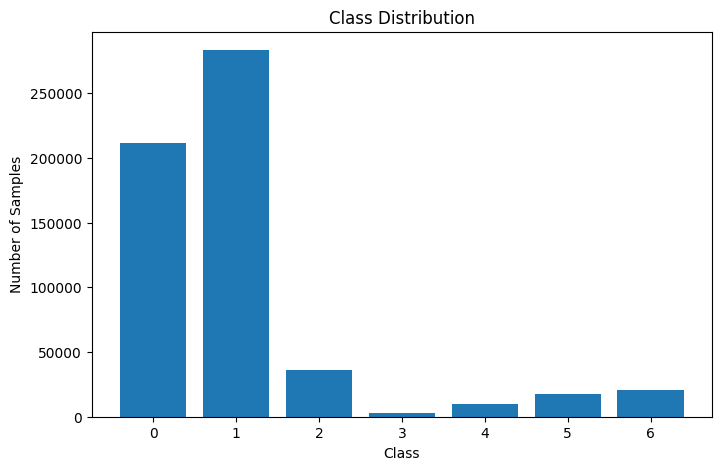


Imbalance Ratio: 103.13105205678923

Data Split:
Training: (464809, 54)
Validation: (58101, 54)
Testing: (58102, 54)

One-hot encoded shape:
(464809, 7)

Class Weights:
Class 0 : 0.39181272253992233
Class 1 : 0.29298131712974634
Class 2 : 2.3214797648598298
Class 3 : 30.209866112049916
Class 4 : 8.743914368486399
Class 5 : 4.779133850171708
Class 6 : 4.046884794873581

Total Parameters: 6247

Starting training...

Epoch: 1 Train Loss: 0.6914 Val Loss: 0.6997 Train Acc: 0.5829 Val Acc: 0.5828
Epoch: 2 Train Loss: 0.6252 Val Loss: 0.6291 Train Acc: 0.6162 Val Acc: 0.6173
Epoch: 3 Train Loss: 0.5844 Val Loss: 0.5923 Train Acc: 0.6375 Val Acc: 0.6383
Epoch: 4 Train Loss: 0.5763 Val Loss: 0.5884 Train Acc: 0.6821 Val Acc: 0.6836
Epoch: 5 Train Loss: 0.5458 Val Loss: 0.5588 Train Acc: 0.6655 Val Acc: 0.6645
Epoch: 6 Train Loss: 0.5251 Val Loss: 0.5324 Train Acc: 0.6753 Val Acc: 0.6763
Epoch: 7 Train Loss: 0.5315 Val Loss: 0.5432 Train Acc: 0.6769 Val Acc: 0.6781
Epoch: 8 Train Loss: 0.5097 

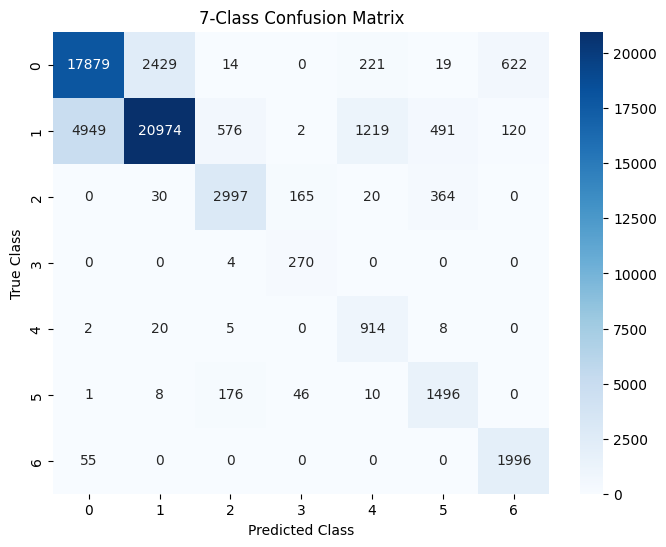

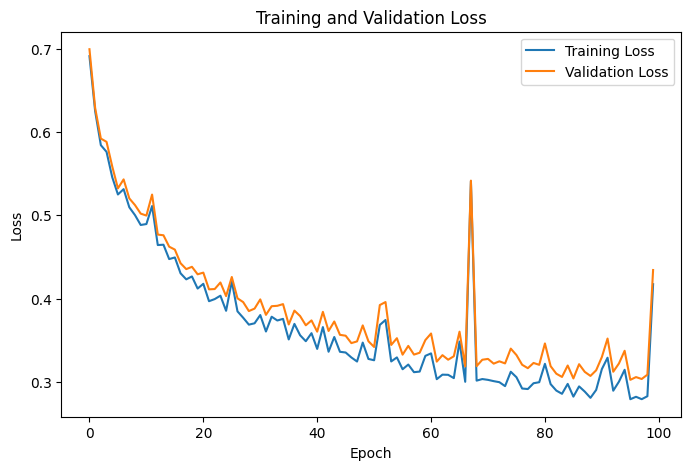

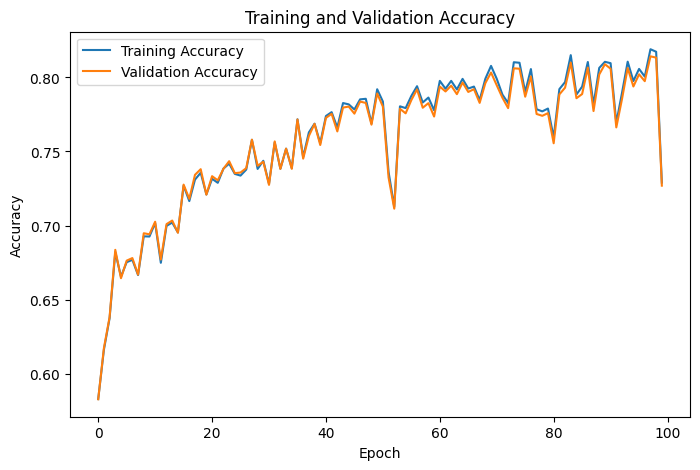

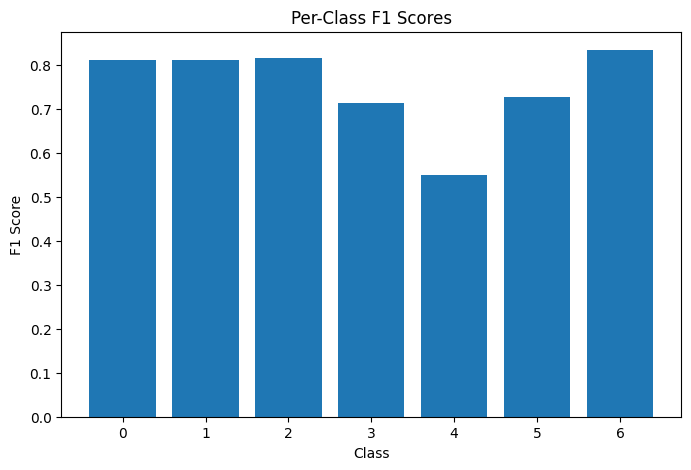

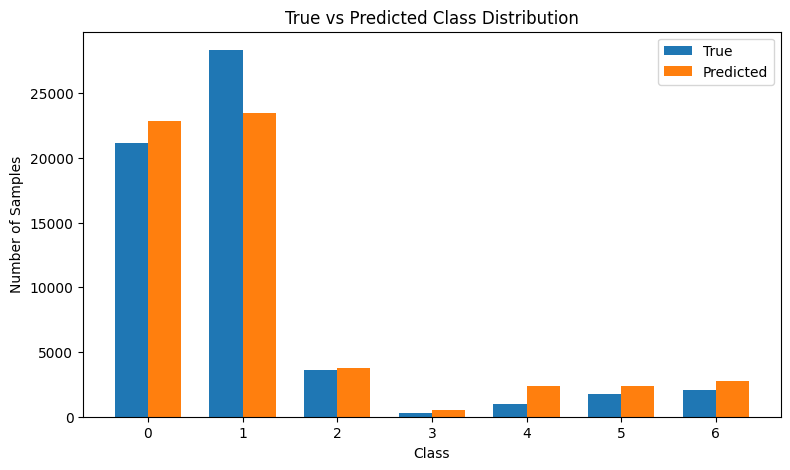

In [2]:
# 1. IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# For reproducible results
np.random.seed(42)


# 2. LOAD COVERTYPE DATASET


print("Loading Covertype dataset...")

data = fetch_covtype()

X = data.data
y = data.target

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)


# 3. CONVERT TARGET 1-7 TO 0-6


y = y - 1

print("\nClasses:")
print(np.unique(y))

print("Number of classes:", len(np.unique(y)))



# 4. CLASS DISTRIBUTION


class_counts = np.bincount(y)

print("\nClass distribution:")

for i in range(7):
    print("Class", i, ":", class_counts[i])


# Plot class distribution

plt.figure(figsize=(8, 5))

plt.bar(range(7), class_counts)

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")

plt.show()


# 5. CALCULATE IMBALANCE RATIO


max_class = np.max(class_counts)
min_class = np.min(class_counts)

imbalance_ratio = max_class / min_class

print("\nImbalance Ratio:", imbalance_ratio)



# 6. TRAIN / VALIDATION / TEST SPLIT


# First split:
# 80% training
# 20% temporary

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


# Split temporary into:
# 10% validation
# 10% testing

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)


print("\nData Split:")
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)



# 7. STANDARDIZE FEATURES


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)



# 8. ONE-HOT ENCODING


num_classes = 7

y_train_onehot = np.eye(num_classes)[y_train]

y_val_onehot = np.eye(num_classes)[y_val]

y_test_onehot = np.eye(num_classes)[y_test]


print("\nOne-hot encoded shape:")
print(y_train_onehot.shape)



# 9. CALCULATE CLASS WEIGHTS


# Formula from PDF:
#
# wc = N / (K * nc)

N = len(y_train)

K = num_classes

class_weights = N / (K * np.bincount(y_train))


print("\nClass Weights:")

for i in range(K):
    print("Class", i, ":", class_weights[i])



# 10. INITIALIZE NETWORK PARAMETERS


# Architecture:
#
# 54 -> 64 -> 32 -> 16 -> 7

input_size = 54
hidden1 = 64
hidden2 = 32
hidden3 = 16
output_size = 7


# He initialization
# Standard deviation = sqrt(2 / number of input neurons)

W1 = np.random.randn(input_size, hidden1) * np.sqrt(2 / input_size)
b1 = np.zeros((1, hidden1))

W2 = np.random.randn(hidden1, hidden2) * np.sqrt(2 / hidden1)
b2 = np.zeros((1, hidden2))

W3 = np.random.randn(hidden2, hidden3) * np.sqrt(2 / hidden2)
b3 = np.zeros((1, hidden3))

W4 = np.random.randn(hidden3, output_size) * np.sqrt(2 / hidden3)
b4 = np.zeros((1, output_size))


# Check total parameters

total_parameters = (
    W1.size + b1.size +
    W2.size + b2.size +
    W3.size + b3.size +
    W4.size + b4.size
)

print("\nTotal Parameters:", total_parameters)



# 11. ACTIVATION FUNCTIONS


def relu(Z):
    return np.maximum(0, Z)


def relu_derivative(Z):
    return (Z > 0).astype(float)


def softmax(Z):

    # Subtract maximum for numerical stability

    Z_shifted = Z - np.max(Z, axis=1, keepdims=True)

    exp_Z = np.exp(Z_shifted)

    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)



# 12. FORWARD PROPAGATION


def forward(X):

    # Layer 1

    Z1 = np.dot(X, W1) + b1

    A1 = relu(Z1)


    # Layer 2

    Z2 = np.dot(A1, W2) + b2

    A2 = relu(Z2)


    # Layer 3

    Z3 = np.dot(A2, W3) + b3

    A3 = relu(Z3)


    # Output layer

    Z4 = np.dot(A3, W4) + b4

    Y_hat = softmax(Z4)


    return Z1, A1, Z2, A2, Z3, A3, Z4, Y_hat


# 13. WEIGHTED CATEGORICAL CROSS-ENTROPY


def compute_loss(Y, Y_hat, labels):

    # Get weight of true class for every sample

    sample_weights = class_weights[labels]

    # Small value to prevent log(0)

    epsilon = 1e-12

    Y_hat = np.clip(Y_hat, epsilon, 1 - epsilon)

    # Cross entropy for each sample

    sample_loss = -np.sum(
        Y * np.log(Y_hat),
        axis=1
    )

    # Apply class weights

    weighted_loss = sample_weights * sample_loss

    return np.mean(weighted_loss)


# 14. BACKPROPAGATION

def backward(
    X,
    Y,
    labels,
    Z1,
    A1,
    Z2,
    A2,
    Z3,
    A3,
    Y_hat
):

    batch_size = X.shape[0]


    # Weight of true class for every sample

    sample_weights = class_weights[labels]

    sample_weights = sample_weights.reshape(-1, 1)


    # Output layer

    dZ4 = sample_weights * (Y_hat - Y)

    dZ4 = dZ4 / batch_size


    dW4 = np.dot(A3.T, dZ4)

    db4 = np.sum(dZ4, axis=0, keepdims=True)


    # Hidden Layer 3


    dA3 = np.dot(dZ4, W4.T)

    dZ3 = dA3 * relu_derivative(Z3)

    dW3 = np.dot(A2.T, dZ3)

    db3 = np.sum(dZ3, axis=0, keepdims=True)



    # Hidden Layer 2


    dA2 = np.dot(dZ3, W3.T)

    dZ2 = dA2 * relu_derivative(Z2)

    dW2 = np.dot(A1.T, dZ2)

    db2 = np.sum(dZ2, axis=0, keepdims=True)



    # Hidden Layer 1


    dA1 = np.dot(dZ2, W2.T)

    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = np.dot(X.T, dZ1)

    db1 = np.sum(dZ1, axis=0, keepdims=True)


    return (
        dW1, db1,
        dW2, db2,
        dW3, db3,
        dW4, db4
    )



# 15. PREDICTION FUNCTION


def predict(X):

    result = forward(X)

    Y_hat = result[-1]

    predictions = np.argmax(Y_hat, axis=1)

    return predictions



# 16. TRAINING SETTINGS


learning_rate = 0.01

batch_size = 128

epochs = 100

patience = 15


# Lists to store training history

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []


# Early stopping variables

best_val_loss = float("inf")

best_parameters = None

patience_counter = 0



# 17. TRAINING LOOP

print("\nStarting training...\n")


for epoch in range(epochs):

    # Shuffle training data

    indices = np.random.permutation(len(X_train))

    X_train_shuffled = X_train[indices]

    y_train_shuffled = y_train[indices]

    Y_train_shuffled = y_train_onehot[indices]


    # Mini-batch training

    for start in range(0, len(X_train), batch_size):

        end = start + batch_size

        X_batch = X_train_shuffled[start:end]

        Y_batch = Y_train_shuffled[start:end]

        labels_batch = y_train_shuffled[start:end]


        # Forward propagation

        (
            Z1,
            A1,
            Z2,
            A2,
            Z3,
            A3,
            Z4,
            Y_hat
        ) = forward(X_batch)


        # Backpropagation

        gradients = backward(
            X_batch,
            Y_batch,
            labels_batch,
            Z1,
            A1,
            Z2,
            A2,
            Z3,
            A3,
            Y_hat
        )


        (
            dW1, db1,
            dW2, db2,
            dW3, db3,
            dW4, db4
        ) = gradients



        # SGD parameter update

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3

        W4 -= learning_rate * dW4
        b4 -= learning_rate * db4



    # Calculate training loss

    train_output = forward(X_train)[-1]

    train_loss = compute_loss(
        y_train_onehot,
        train_output,
        y_train
    )


    # Calculate validation loss


    val_output = forward(X_val)[-1]

    val_loss = compute_loss(
        y_val_onehot,
        val_output,
        y_val
    )


    # Accuracy


    train_predictions = np.argmax(
        train_output,
        axis=1
    )

    val_predictions = np.argmax(
        val_output,
        axis=1
    )


    train_accuracy = accuracy_score(
        y_train,
        train_predictions
    )

    val_accuracy = accuracy_score(
        y_val,
        val_predictions
    )


    # Store history

    train_losses.append(train_loss)

    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)

    val_accuracies.append(val_accuracy)



    # Early stopping

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        patience_counter = 0

        # Save best parameters

        best_parameters = [
            W1.copy(), b1.copy(),
            W2.copy(), b2.copy(),
            W3.copy(), b3.copy(),
            W4.copy(), b4.copy()
        ]

    else:

        patience_counter += 1


    print(
        "Epoch:",
        epoch + 1,
        "Train Loss:",
        round(train_loss, 4),
        "Val Loss:",
        round(val_loss, 4),
        "Train Acc:",
        round(train_accuracy, 4),
        "Val Acc:",
        round(val_accuracy, 4)
    )


    if patience_counter >= patience:

        print("\nEarly stopping activated.")

        break

# 18. RESTORE BEST MODEL

(
    W1, b1,
    W2, b2,
    W3, b3,
    W4, b4
) = best_parameters


print("\nBest validation loss:", best_val_loss)

# 19. TEST PREDICTION


test_output = forward(X_test)[-1]

y_pred = np.argmax(
    test_output,
    axis=1
)



# 20. ACCURACY


accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nTest Accuracy:", accuracy)



# 21. PRECISION

precision = precision_score(
    y_test,
    y_pred,
    average=None,
    zero_division=0
)

macro_precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)


# 22. RECALL

recall = recall_score(
    y_test,
    y_pred,
    average=None,
    zero_division=0
)

macro_recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)


# 23. F1 SCORE


f1 = f1_score(
    y_test,
    y_pred,
    average=None,
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

# 24. PRINT RESULTS


print("\n==========================================")
print("FINAL RESULTS")
print("==========================================")

print("\nAccuracy:", round(accuracy, 4))

print("\nPer-Class Precision:")

for i in range(7):
    print("Class", i, ":", round(precision[i], 4))

print("\nPer-Class Recall:")

for i in range(7):
    print("Class", i, ":", round(recall[i], 4))

print("\nPer-Class F1 Score:")

for i in range(7):
    print("Class", i, ":", round(f1[i], 4))


print("\nMacro Precision:", round(macro_precision, 4))

print("Macro Recall:", round(macro_recall, 4))

print("Macro F1:", round(macro_f1, 4))



# 25. CLASSIFICATION REPORT


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

# 26. CONFUSION MATRIX


cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Class")

plt.ylabel("True Class")

plt.title("7-Class Confusion Matrix")

plt.show()


# 27. TRAINING AND VALIDATION LOSS


plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.legend()

plt.show()


# 28. TRAINING AND VALIDATION ACCURACY


plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training and Validation Accuracy")

plt.legend()

plt.show()

# 29. PER-CLASS F1 SCORE


plt.figure(figsize=(8, 5))

plt.bar(
    range(7),
    f1
)

plt.xlabel("Class")

plt.ylabel("F1 Score")

plt.title("Per-Class F1 Scores")

plt.xticks(range(7))

plt.show()



# 30. TRUE VS PREDICTED CLASS DISTRIBUTION


true_counts = np.bincount(
    y_test,
    minlength=7
)

pred_counts = np.bincount(
    y_pred,
    minlength=7
)


x = np.arange(7)

width = 0.35


plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    true_counts,
    width,
    label="True"
)

plt.bar(
    x + width / 2,
    pred_counts,
    width,
    label="Predicted"
)

plt.xlabel("Class")

plt.ylabel("Number of Samples")

plt.title("True vs Predicted Class Distribution")

plt.xticks(x)

plt.legend()

plt.show()